In [27]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\tanay\Downloads\Churn_Modelling (3).csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39.0,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35.0,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36.0,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1,0,92888.52,1


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           9997 non-null   str    
 6   Age              9997 non-null   float64
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB


In [29]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,9997.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921376,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.485953,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [30]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             3
Age                3
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [31]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])


In [32]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Exited
0    7963
1    2037
Name: count, dtype: int64


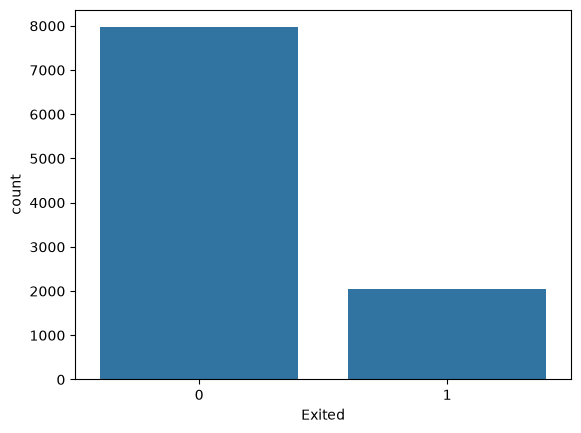

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="Exited",data = df)
print(df['Exited'].value_counts())

In [34]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

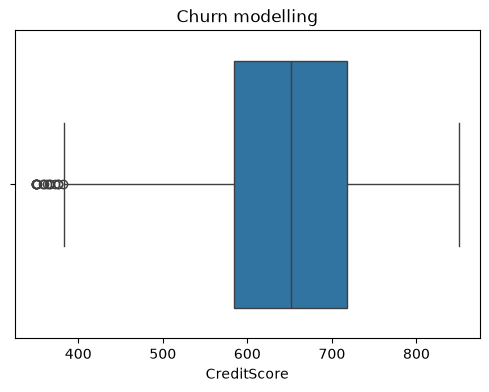

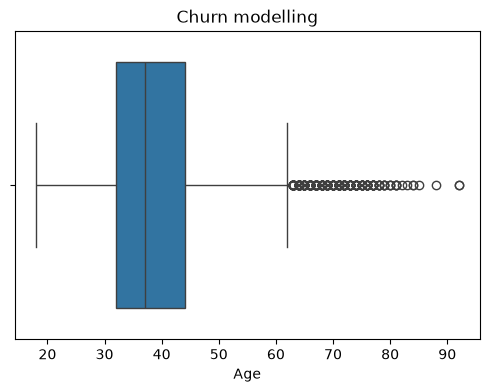

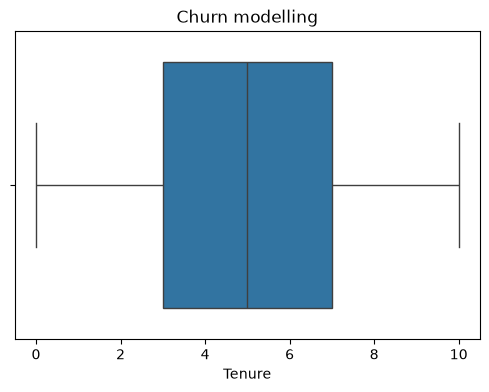

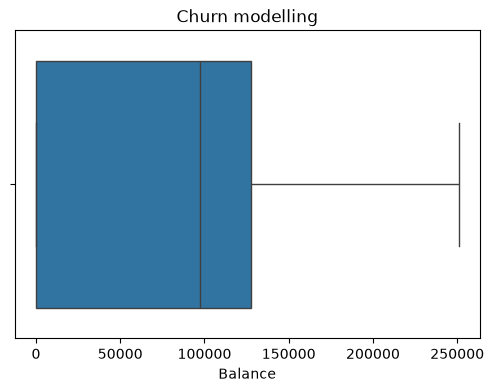

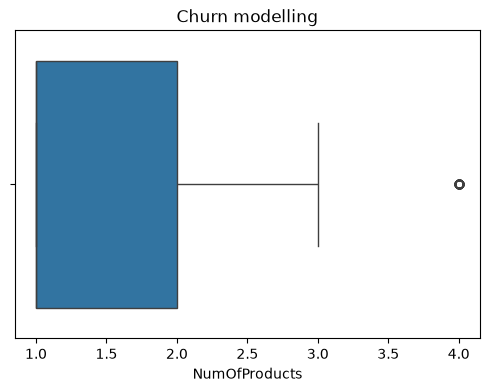

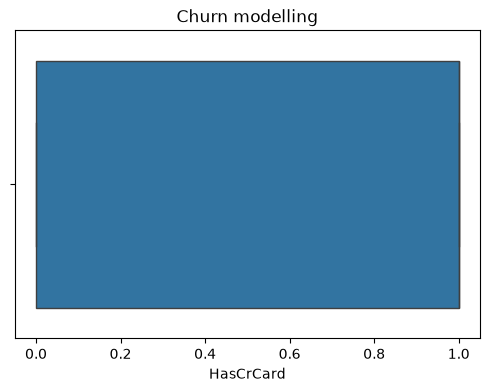

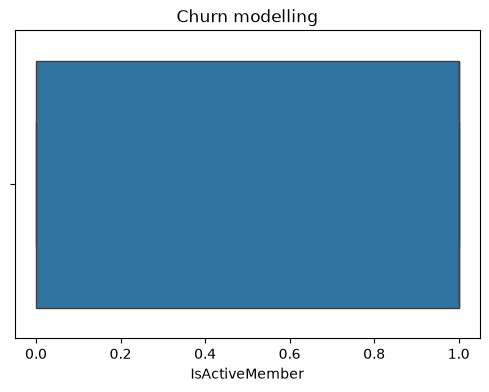

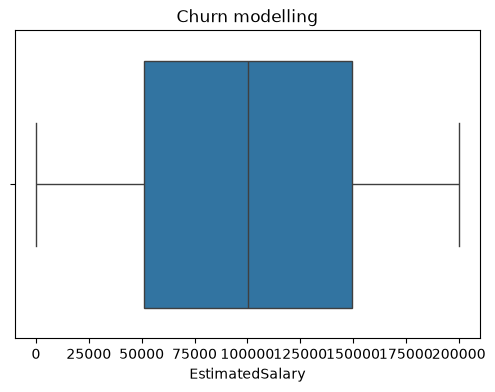

In [35]:
nums = ['CreditScore', 
        'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary']
for col in nums:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = col,data = df)
    plt.title("Churn modelling")
    plt.xlabel(col)
    
    

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x = df.drop(
    ['RowNumber', 'CustomerId', 'Surname','Exited'],
    axis=1)
x.shape

(10000, 10)

In [37]:
y = df["Exited"]
y.shape

(10000,)

In [38]:
x = pd.get_dummies(
x,
columns=['Geography', 'Gender'],
drop_first=True
)

In [39]:
# from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
precision_score,
recall_score,
f1_score
)
from imblearn.over_sampling import SMOTE

In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 42,test_size = 0.2,stratify=y)
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)


In [43]:
print("Before SMOTE",y.value_counts()) 

Before SMOTE Exited
0    7963
1    2037
Name: count, dtype: int64


In [45]:
smote = SMOTE(random_state=42)
x_train_bal,y_train_bal = smote.fit_resample(x_train_scaled,y_train)
print("After SMOTE: ",y_train_bal.value_counts())

After SMOTE:  Exited
1    6370
0    6370
Name: count, dtype: int64


In [48]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train_bal,y_train_bal)
y_pred = nb.predict(x_test_scaled)

In [50]:
y_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [51]:
y_test[:20]

5702    0
3667    0
1617    0
5673    0
4272    0
8270    0
7079    0
5295    0
845     0
5311    0
7068    1
5219    0
5495    0
6151    0
5622    0
2636    0
5061    0
3563    0
2350    1
4509    0
Name: Exited, dtype: int64

In [52]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7135
Precision: 0.3850415512465374
Recall : 0.683046683046683
F1 Score : 0.4924712134632418

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.68      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.79      0.71      0.74      2000



In [54]:
nb2 = GaussianNB()
nb2.fit(x_train_scaled,y_train)

y_pred_unb = nb2.predict(x_test_scaled)

In [55]:
print("Accuracy :", accuracy_score(y_test, y_pred_unb))
print("Precision:", precision_score(y_test, y_pred_unb))
print("Recall :", recall_score(y_test, y_pred_unb))
print("F1 Score :", f1_score(y_test, y_pred_unb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_unb))

Accuracy : 0.82
Precision: 0.6
Recall : 0.3464373464373464
F1 Score : 0.4392523364485981

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1593
           1       0.60      0.35      0.44       407

    accuracy                           0.82      2000
   macro avg       0.72      0.64      0.67      2000
weighted avg       0.80      0.82      0.80      2000

